# k-Nearest Neighbors (kNN) from Scratch

In this notebook, we will develop a Python implementation of the kNN algorithm from scratch. Our primary focus is on **educational clarity**. To make the logic easy to follow, we will build the algorithm using modular functions rather than a class structure.

The kNN algorithm consists of three main steps:
1. Calculate the distance between a test point and all training points.
2. Find the $k$ nearest neighbors (the points with the smallest distances).
3. Make a prediction based on the majority vote of the neighbors' labels.

## 1. Calculate Distance

First, we need a way to measure how "close" two data points are. We will use the **Euclidean distance**. For two vectors `x1` and `x2`, the Euclidean distance is the square root of the sum of squared differences of their components.

In [1]:
import numpy as np
from collections import Counter

def euclidean_distance(x1, x2):
    """
    Calculate Euclidean distance between two data points.
    """
    # 1. Compute the squared differences: (x1 - x2)**2
    # 2. Sum the squared differences: np.sum(...)
    # 3. Take the square root: np.sqrt(...)
    return np.sqrt(np.sum((x1 - x2)**2))

## 2. Get Nearest Neighbors

Next, we write a function to find the $k$ closest training points to a single test point. We calculate the distance between the `test_point` and every point in `X_train`, then we sort these distances to find the indices of the $k$ smallest ones.

In [3]:
def get_neighbors(X_train, y_train, test_point, k=3):
    """
    Find the labels of the k nearest neighbors for a given test point.
    """
    # Compute the distance from the test_point to all points in X_train
    distances = [euclidean_distance(test_point, x_train) for x_train in X_train]
    
    # np.argsort returns the indices that would sort the distances array
    # We slice [:k] to get the indices of the k smallest distances
    k_indices = np.argsort(distances)[:k]
    
    # Retrieve the corresponding labels from y_train
    k_nearest_labels = [y_train[i] for i in k_indices]
    
    return k_nearest_labels

## 3. Make Prediction

Once we have the labels of the $k$ nearest neighbors, we determine the most common label among them. This is the "majority vote" step.

In [4]:
def predict_classification(k_nearest_labels):
    """
    Predict the class based on a majority vote from the neighbors.
    """
    # Counter counts the frequency of each label (e.g., {label_1: count, label_2: count})
    most_common = Counter(k_nearest_labels).most_common(1)
    
    # most_common(1) returns a list with the single most common element and its count:
    # e.g., [(label, count)] 
    # We extract the label with most_common[0][0]
    return most_common[0][0]

## 4. Putting It All Together

Now we create a wrapper function `knn_predict` that takes the entire training dataset and the test dataset, and predicts the label for every test point in `X_test`.

In [5]:
def knn_predict(X_train, y_train, X_test, k=3):
    """
    Predict labels for all test data points.
    """
    predictions = []
    for test_point in X_test:
        # Find the k nearest labels
        neighbors_labels = get_neighbors(X_train, y_train, test_point, k)
        # Get the majority vote prediction
        pred = predict_classification(neighbors_labels)
        predictions.append(pred)
        
    return np.array(predictions)

## 5. Test the Implementation

Let's test our scratch implementation on the classic **Iris dataset**. We'll load the data, split it into training and testing sets, use our functions to predict the test set labels, and then calculate our accuracy.

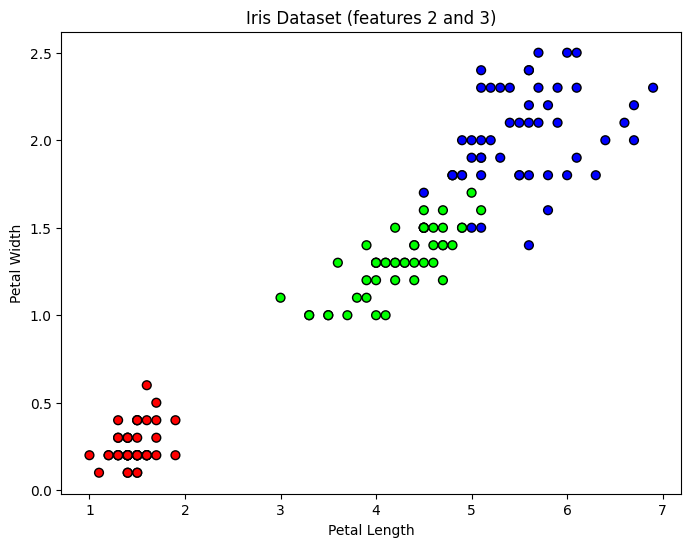

In [7]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Load dataset
iris = datasets.load_iris()
X, y = iris.data, iris.target

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

# Visualize a slice of the dataset (using feature index 2 and 3)
cmap = ListedColormap(['#FF0000','#00FF00','#0000FF'])
plt.figure(figsize=(8,6))
plt.scatter(X[:, 2], X[:, 3], c=y, cmap=cmap, edgecolor='k', s=40)
plt.title("Iris Dataset (features 2 and 3)")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

In [9]:
# Run our kNN implementation
k = 5
predictions = knn_predict(X_train, y_train, X_test, k=k)

print("Predictions:\n", predictions)
print("True labels:\n", y_test)

# Calculate accuracy
accuracy = np.sum(predictions == y_test) / len(y_test)
print(f"\nAccuracy: {accuracy:.4f}")

Predictions:
 [1 2 2 0 1 0 0 0 1 2 1 0 2 1 0 1 2 0 2 1 1 1 1 1 2 0 2 1 2 0]
True labels:
 [1 1 2 0 1 0 0 0 1 2 1 0 2 1 0 1 2 0 2 1 1 1 1 1 2 0 2 1 2 0]

Accuracy: 0.9667
